In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [00:55<00:00, 127MB/s] 

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess the data**

* 10 base classes -> build the group-disjoint split and write the
clips

In [5]:
base_split = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
clashes    = describe_group_split(base_split, cfg.SELECTED_CLASSES)

split      clips   percent  clips/class
---------------------------------------
train        953     71.7%         95.3
val          165     12.4%         16.5
test         212     15.9%         21.2
---------------------------------------
TOTAL       1330                  133.0

groups: 250   groups in >1 split: 0
OK - group-disjoint.


In [6]:
# BASE
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [7]:
class_to_idx = {cls_name: i for i, cls_name in enumerate(cfg.SELECTED_CLASSES)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9}


## **DataLoaders**

In [8]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_val   = UCF101Clips(os.path.join(cfg.BASE_ROOT, "val"),   class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)

train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(base_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(base_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train {len(base_train)}  val {len(base_val)}  test {len(base_test)}")

train 953  val 165  test 212


## **Training setup**

In [9]:
EPOCHS = 5
TRIALS = []

## **ScratchCNN + LSTM**

In [10]:
scratch = ScratchCNNLSTM().to(device)

In [11]:
summary(scratch, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ScratchCNNLSTM                           [1, 10]                   --
├─Conv2d: 1-1                            [16, 32, 224, 224]        896
├─MaxPool2d: 1-2                         [16, 32, 112, 112]        --
├─Conv2d: 1-3                            [16, 64, 112, 112]        18,496
├─MaxPool2d: 1-4                         [16, 64, 56, 56]          --
├─Conv2d: 1-5                            [16, 128, 56, 56]         73,856
├─MaxPool2d: 1-6                         [16, 128, 28, 28]         --
├─LSTM: 1-7                              [1, 16, 256]              103,024,640
├─Linear: 1-8                            [1, 10]                   2,570
Total params: 103,120,458
Trainable params: 103,120,458
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.79
Input size (MB): 9.63
Forward/backward pass size (MB): 359.69
Params size (MB): 412.48
Estimated Total Size (MB): 781.81

In [12]:
set_seed(cfg.SEED)
hist_scratch = train_model(scratch, train_loader, val_loader, num_epochs=EPOCHS, device=device)

Epoch [1/5] | Train Acc: 0.3494 Loss: 1.9599 | Val Acc: 0.4364 Loss: 1.8079


Epoch [2/5] | Train Acc: 0.6128 Loss: 1.4376 | Val Acc: 0.5091 Loss: 1.5504


Epoch [3/5] | Train Acc: 0.7838 Loss: 1.0391 | Val Acc: 0.5152 Loss: 1.4323


Epoch [4/5] | Train Acc: 0.8562 Loss: 0.7703 | Val Acc: 0.5879 Loss: 1.3583


Epoch [5/5] | Train Acc: 0.9297 Loss: 0.5689 | Val Acc: 0.4909 Loss: 1.4380


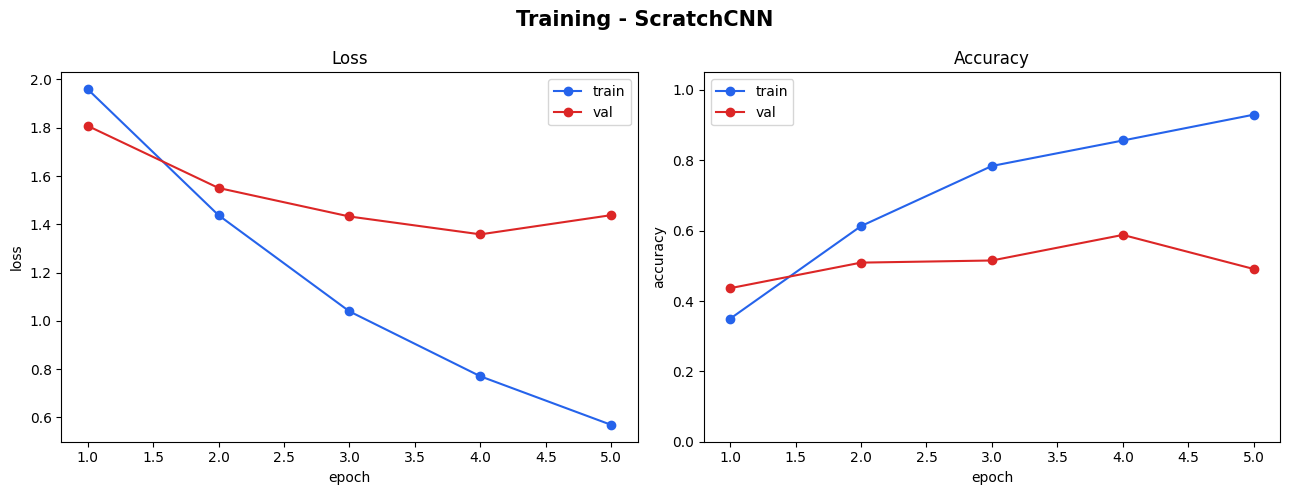

In [13]:
plot_training_results(hist_scratch, task_name="ScratchCNN")

In [14]:
acc_scratch, preds_scratch, labels_scratch = test_model(scratch, test_loader, device)

Test Accuracy: 0.5283


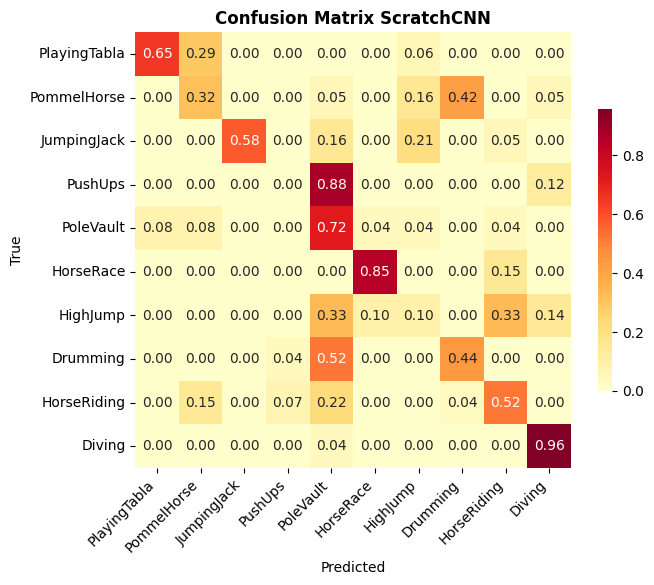

In [15]:
plot_confusion_matrix(labels_scratch, preds_scratch, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="ScratchCNN")

In [16]:
print_detailed_metrics(labels_scratch, preds_scratch, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES)


METRICS FOR 10 CLASSES
  Accuracy : 0.5283
  F1-Score : 0.5138

PER-CLASS REPORT
              precision    recall  f1-score   support

PlayingTabla       0.85      0.65      0.73        17
 PommelHorse       0.35      0.32      0.33        19
 JumpingJack       1.00      0.58      0.73        19
     PushUps       0.00      0.00      0.00        16
   PoleVault       0.29      0.72      0.41        25
   HorseRace       0.85      0.85      0.85        20
    HighJump       0.18      0.10      0.12        21
    Drumming       0.55      0.44      0.49        25
 HorseRiding       0.54      0.52      0.53        27
      Diving       0.79      0.96      0.86        23

    accuracy                           0.53       212
   macro avg       0.54      0.51      0.51       212
weighted avg       0.54      0.53      0.51       212



In [17]:
params_scratch = sum(p.numel() for p in scratch.parameters())
TRIALS.append({"name": "ScratchCNN", "test_acc": acc_scratch, "best_val": max(hist_scratch["val_accs"]), "params_M": params_scratch / 1e6, "size_MB": params_scratch * 4 / 1e6, "ms_per_clip": measure_latency(scratch, test_loader, device)})

## **ResNet18 + LSTM**

In [18]:
resnet18 = ResNet18LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [19]:
summary(resnet18, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet18LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 512, 1, 1]           --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 64, 56, 56]          --
│    │    └─BasicBlock: 3-1                   [16, 64, 56, 56]          (73,984)
│    │    └─BasicBlock: 3-2                   [16, 64, 56, 56]          (73,984)
│    └─Sequential: 2-6                        [16, 128, 28, 28]         --
│    │    └─BasicBlock: 3-3                   [16, 128, 28, 28]         (230,144)
│    │    └─BasicBlock: 3-4                   [16, 128, 28, 28]     

In [20]:
set_seed(cfg.SEED)
hist_resnet18 = train_model(resnet18, train_loader, val_loader, num_epochs=EPOCHS, device=device)

Epoch [1/5] | Train Acc: 0.7545 Loss: 1.1206 | Val Acc: 0.9212 Loss: 0.3889


Epoch [2/5] | Train Acc: 0.9675 Loss: 0.1959 | Val Acc: 0.9273 Loss: 0.2880


Epoch [3/5] | Train Acc: 0.9843 Loss: 0.1057 | Val Acc: 0.9394 Loss: 0.1836


Epoch [4/5] | Train Acc: 0.9906 Loss: 0.0670 | Val Acc: 0.9333 Loss: 0.2103


Epoch [5/5] | Train Acc: 0.9958 Loss: 0.0525 | Val Acc: 0.9455 Loss: 0.1617


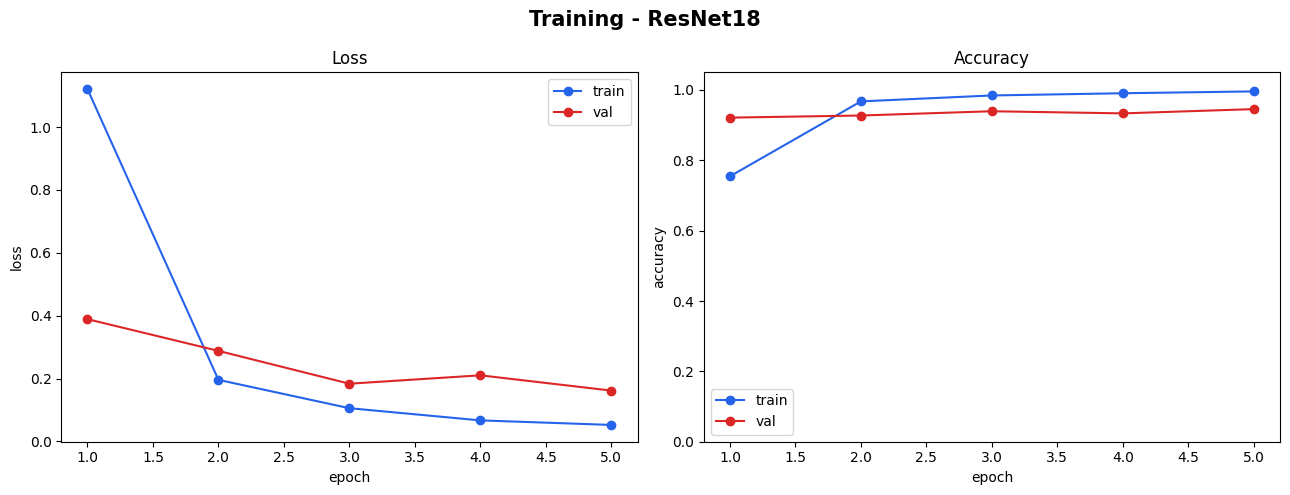

In [21]:
plot_training_results(hist_resnet18, task_name="ResNet18")

In [22]:
acc_resnet18, preds_resnet18, labels_resnet18 = test_model(resnet18, test_loader, device)

Test Accuracy: 0.9009


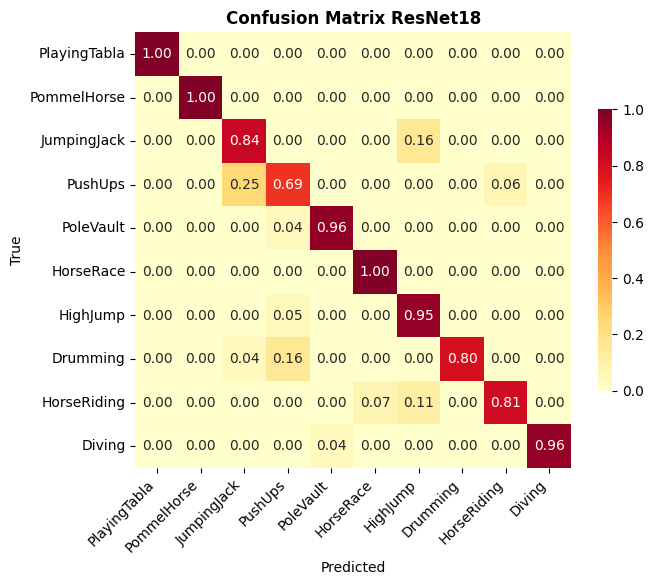

In [23]:
plot_confusion_matrix(labels_resnet18, preds_resnet18, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="ResNet18")

In [24]:
print_detailed_metrics(labels_resnet18, preds_resnet18, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES)


METRICS FOR 10 CLASSES
  Accuracy : 0.9009
  F1-Score : 0.9022

PER-CLASS REPORT
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        17
 PommelHorse       1.00      1.00      1.00        19
 JumpingJack       0.76      0.84      0.80        19
     PushUps       0.65      0.69      0.67        16
   PoleVault       0.96      0.96      0.96        25
   HorseRace       0.91      1.00      0.95        20
    HighJump       0.77      0.95      0.85        21
    Drumming       1.00      0.80      0.89        25
 HorseRiding       0.96      0.81      0.88        27
      Diving       1.00      0.96      0.98        23

    accuracy                           0.90       212
   macro avg       0.90      0.90      0.90       212
weighted avg       0.91      0.90      0.90       212



In [25]:
params_resnet18 = sum(p.numel() for p in resnet18.parameters())
TRIALS.append({"name": "ResNet18", "test_acc": acc_resnet18, "best_val": max(hist_resnet18["val_accs"]), "params_M": params_resnet18 / 1e6, "size_MB": params_resnet18 * 4 / 1e6, "ms_per_clip": measure_latency(resnet18, test_loader, device)})

## **ResNet50 + LSTM**

In [26]:
resnet50 = ResNet50LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s] 


In [27]:
summary(resnet50, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet50LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 2048, 1, 1]          --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 56, 56]         (75,008)
│    │    └─Bottleneck: 3-2                   [16, 256, 56, 56]         (70,400)
│    │    └─Bottleneck: 3-3                   [16, 256, 56, 56]         (70,400)
│    └─Sequential: 2-6                        [16, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [16, 512, 28, 28]      

In [28]:
set_seed(cfg.SEED)
hist_resnet50 = train_model(resnet50, train_loader, val_loader, num_epochs=EPOCHS, device=device)

Epoch [1/5] | Train Acc: 0.6254 Loss: 1.3729 | Val Acc: 0.9030 Loss: 0.5829


Epoch [2/5] | Train Acc: 0.9433 Loss: 0.2822 | Val Acc: 0.9394 Loss: 0.3155


Epoch [3/5] | Train Acc: 0.9727 Loss: 0.1408 | Val Acc: 0.9394 Loss: 0.2561


Epoch [4/5] | Train Acc: 0.9895 Loss: 0.0822 | Val Acc: 0.9515 Loss: 0.1606


Epoch [5/5] | Train Acc: 0.9895 Loss: 0.0697 | Val Acc: 0.9394 Loss: 0.1749


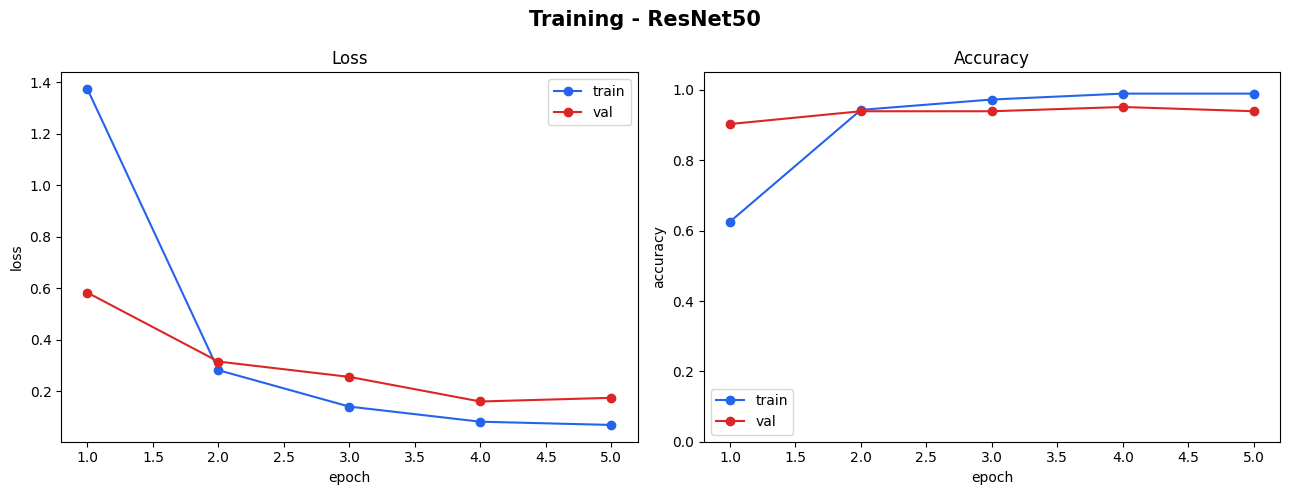

In [29]:
plot_training_results(hist_resnet50, task_name="ResNet50")

In [30]:
acc_resnet50, preds_resnet50, labels_resnet50 = test_model(resnet50, test_loader, device)

Test Accuracy: 0.9387


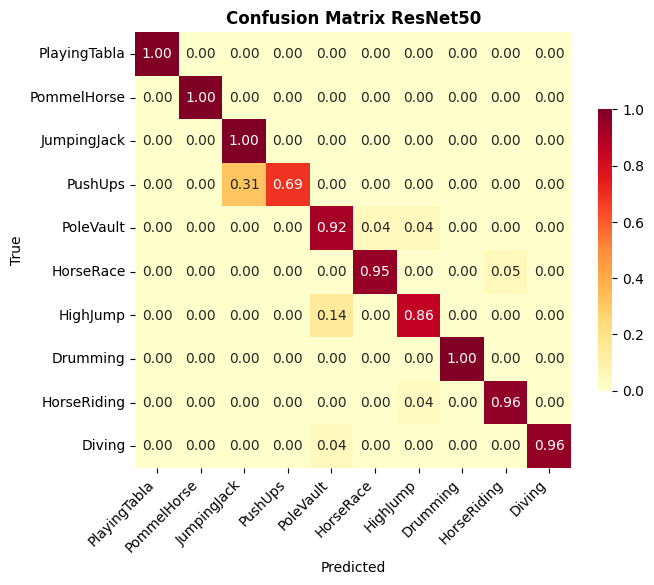

In [31]:
plot_confusion_matrix(labels_resnet50, preds_resnet50, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="ResNet50")

In [32]:
print_detailed_metrics(labels_resnet50, preds_resnet50, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES)


METRICS FOR 10 CLASSES
  Accuracy : 0.9387
  F1-Score : 0.9381

PER-CLASS REPORT
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        17
 PommelHorse       1.00      1.00      1.00        19
 JumpingJack       0.79      1.00      0.88        19
     PushUps       1.00      0.69      0.81        16
   PoleVault       0.85      0.92      0.88        25
   HorseRace       0.95      0.95      0.95        20
    HighJump       0.90      0.86      0.88        21
    Drumming       1.00      1.00      1.00        25
 HorseRiding       0.96      0.96      0.96        27
      Diving       1.00      0.96      0.98        23

    accuracy                           0.94       212
   macro avg       0.95      0.93      0.94       212
weighted avg       0.94      0.94      0.94       212



In [33]:
params_resnet50 = sum(p.numel() for p in resnet50.parameters())
TRIALS.append({"name": "ResNet50", "test_acc": acc_resnet50, "best_val": max(hist_resnet50["val_accs"]), "params_M": params_resnet50 / 1e6, "size_MB": params_resnet50 * 4 / 1e6, "ms_per_clip": measure_latency(resnet50, test_loader, device)})

## **DenseNet121 + LSTM**

In [34]:
densenet121 = DenseNet121LSTM().to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 131MB/s]


In [35]:
summary(densenet121, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet121LSTM                          [1, 10]                   --
├─Sequential: 1-1                        [16, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [16, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [16, 32, 56, 56]          (45,440)
│    │    └─_DenseLayer: 3-2             [16, 32, 56, 56]          (49,600)
│    │    └─_DenseLayer: 3-3             [16, 32, 56, 56]          (53,760)
│    │    └─_DenseLayer: 3-4             [16, 32, 56, 56]          (57,920)
│    │    └─_DenseLayer: 3-5             [16, 32, 56, 56]          (62,080)
│    │    └─_DenseLayer: 3-6             [16, 3

In [36]:
set_seed(cfg.SEED)
hist_densenet121 = train_model(densenet121, train_loader, val_loader, num_epochs=EPOCHS, device=device)

Epoch [1/5] | Train Acc: 0.6821 Loss: 1.4334 | Val Acc: 0.8727 Loss: 0.7867


Epoch [2/5] | Train Acc: 0.9412 Loss: 0.3479 | Val Acc: 0.9091 Loss: 0.3986


Epoch [3/5] | Train Acc: 0.9748 Loss: 0.1510 | Val Acc: 0.9030 Loss: 0.3170


Epoch [4/5] | Train Acc: 0.9895 Loss: 0.0902 | Val Acc: 0.8970 Loss: 0.3007


Epoch [5/5] | Train Acc: 0.9874 Loss: 0.0718 | Val Acc: 0.8909 Loss: 0.3025


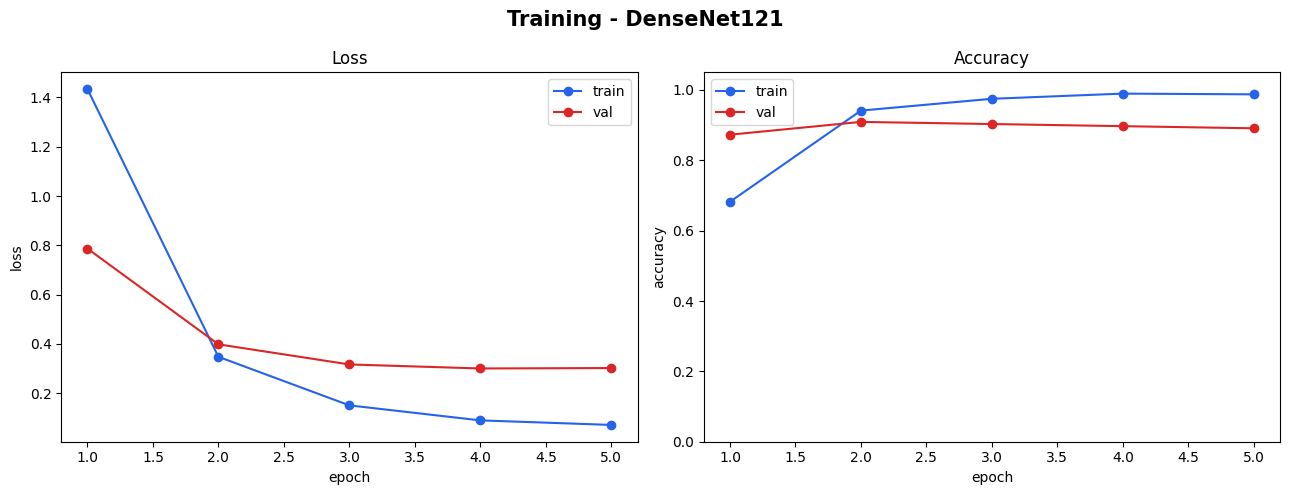

In [37]:
plot_training_results(hist_densenet121, task_name="DenseNet121")

In [38]:
acc_densenet121, preds_densenet121, labels_densenet121 = test_model(densenet121, test_loader, device)

Test Accuracy: 0.9198


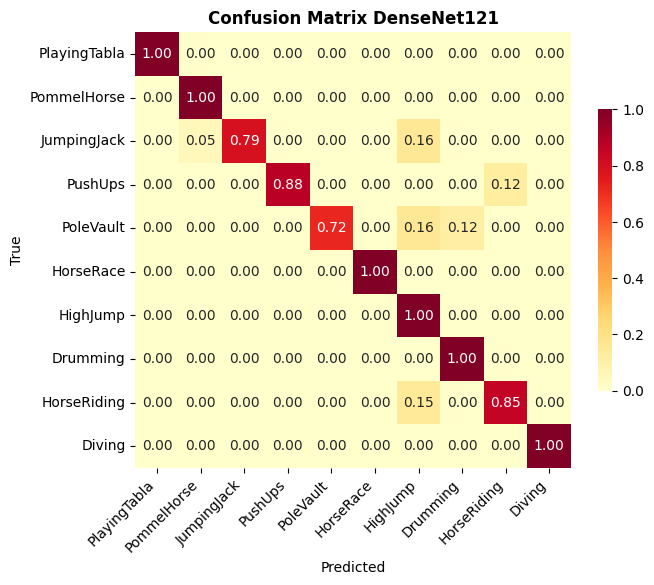

In [39]:
plot_confusion_matrix(labels_densenet121, preds_densenet121, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="DenseNet121")

In [40]:
print_detailed_metrics(labels_densenet121, preds_densenet121, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES)


METRICS FOR 10 CLASSES
  Accuracy : 0.9198
  F1-Score : 0.9210

PER-CLASS REPORT
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        17
 PommelHorse       0.95      1.00      0.97        19
 JumpingJack       1.00      0.79      0.88        19
     PushUps       1.00      0.88      0.93        16
   PoleVault       1.00      0.72      0.84        25
   HorseRace       1.00      1.00      1.00        20
    HighJump       0.66      1.00      0.79        21
    Drumming       0.89      1.00      0.94        25
 HorseRiding       0.92      0.85      0.88        27
      Diving       1.00      1.00      1.00        23

    accuracy                           0.92       212
   macro avg       0.94      0.92      0.92       212
weighted avg       0.94      0.92      0.92       212



In [41]:
params_densenet121 = sum(p.numel() for p in densenet121.parameters())
TRIALS.append({"name": "DenseNet121", "test_acc": acc_densenet121, "best_val": max(hist_densenet121["val_accs"]), "params_M": params_densenet121 / 1e6, "size_MB": params_densenet121 * 4 / 1e6, "ms_per_clip": measure_latency(densenet121, test_loader, device)})

## **VGG19-BN + LSTM**

In [42]:
vgg19 = VGG19BNLSTM().to(device)

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:06<00:00, 87.6MB/s] 


In [43]:
summary(vgg19, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG19BNLSTM                              [1, 10]                   --
├─Sequential: 1-1                        [16, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [16, 64, 224, 224]        (1,792)
│    └─BatchNorm2d: 2-2                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-3                         [16, 64, 224, 224]        --
│    └─Conv2d: 2-4                       [16, 64, 224, 224]        (36,928)
│    └─BatchNorm2d: 2-5                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-6                         [16, 64, 224, 224]        --
│    └─MaxPool2d: 2-7                    [16, 64, 112, 112]        --
│    └─Conv2d: 2-8                       [16, 128, 112, 112]       (73,856)
│    └─BatchNorm2d: 2-9                  [16, 128, 112, 112]       (256)
│    └─ReLU: 2-10                        [16, 128, 112, 112]       --
│    └─Conv2d: 2-11                      [16, 128, 112, 112

In [44]:
set_seed(cfg.SEED)
hist_vgg19 = train_model(vgg19, train_loader, val_loader, num_epochs=EPOCHS, device=device)

Epoch [1/5] | Train Acc: 0.6013 Loss: 1.4200 | Val Acc: 0.9030 Loss: 0.5508


Epoch [2/5] | Train Acc: 0.9328 Loss: 0.2685 | Val Acc: 0.8545 Loss: 0.4901


Epoch [3/5] | Train Acc: 0.9559 Loss: 0.1842 | Val Acc: 0.9091 Loss: 0.3974


Epoch [4/5] | Train Acc: 0.9801 Loss: 0.0906 | Val Acc: 0.9333 Loss: 0.2461


Epoch [5/5] | Train Acc: 0.9853 Loss: 0.0797 | Val Acc: 0.9091 Loss: 0.2957


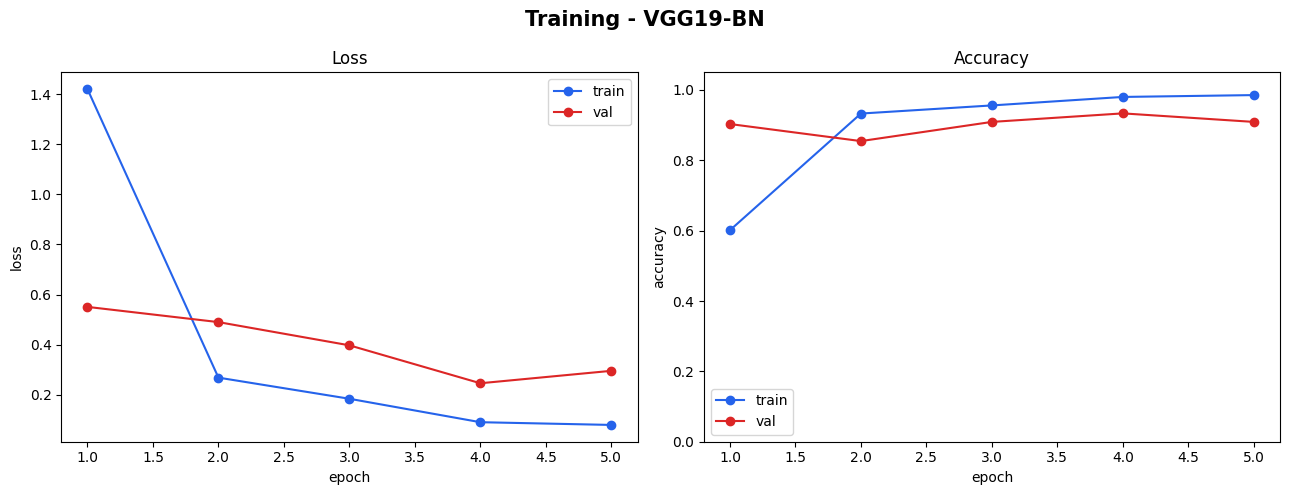

In [45]:
plot_training_results(hist_vgg19, task_name="VGG19-BN")

In [46]:
acc_vgg19, preds_vgg19, labels_vgg19 = test_model(vgg19, test_loader, device)

Test Accuracy: 0.9198


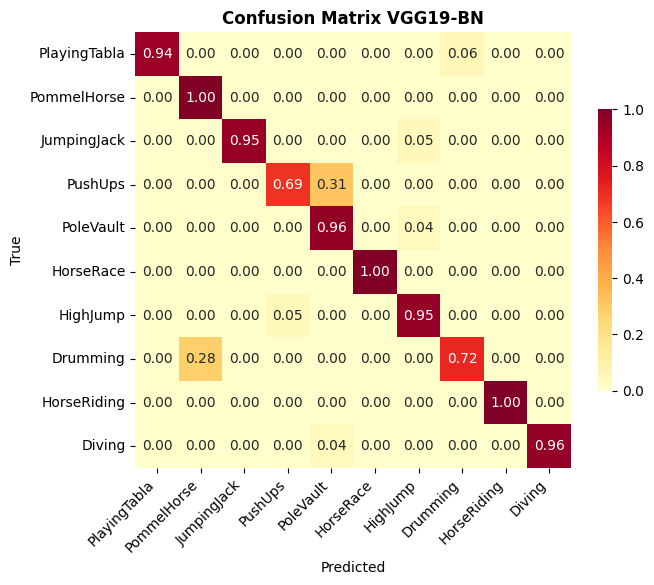

In [47]:
plot_confusion_matrix(labels_vgg19, preds_vgg19, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="VGG19-BN")

In [48]:
print_detailed_metrics(labels_vgg19, preds_vgg19, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES)


METRICS FOR 10 CLASSES
  Accuracy : 0.9198
  F1-Score : 0.9193

PER-CLASS REPORT
              precision    recall  f1-score   support

PlayingTabla       1.00      0.94      0.97        17
 PommelHorse       0.73      1.00      0.84        19
 JumpingJack       1.00      0.95      0.97        19
     PushUps       0.92      0.69      0.79        16
   PoleVault       0.80      0.96      0.87        25
   HorseRace       1.00      1.00      1.00        20
    HighJump       0.91      0.95      0.93        21
    Drumming       0.95      0.72      0.82        25
 HorseRiding       1.00      1.00      1.00        27
      Diving       1.00      0.96      0.98        23

    accuracy                           0.92       212
   macro avg       0.93      0.92      0.92       212
weighted avg       0.93      0.92      0.92       212



In [49]:
params_vgg19 = sum(p.numel() for p in vgg19.parameters())
TRIALS.append({"name": "VGG19-BN", "test_acc": acc_vgg19, "best_val": max(hist_vgg19["val_accs"]), "params_M": params_vgg19 / 1e6, "size_MB": params_vgg19 * 4 / 1e6, "ms_per_clip": measure_latency(vgg19, test_loader, device)})

## **Compare**

In [50]:
results_df = pd.DataFrame(TRIALS).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df

,name,test_acc,best_val,params_M,size_MB,ms_per_clip
0,ResNet50,0.938679,0.951515,25.871946,103.487784,54.648730
1,VGG19-BN,0.919811,0.933333,20.826442,83.305768,115.695772
2,DenseNet121,0.919811,0.909091,8.269194,33.076776,53.119108
3,ResNet18,0.900943,0.945455,11.967562,47.870248,15.680695
4,ScratchCNN,0.528302,0.587879,103.120458,412.481832,10.245782


In [51]:
best = results_df.iloc[0]
print(f"highest accuracy : {best['name']}  {best['test_acc']:.2%}")
print(f"chosen teacher   : ResNet50  (accuracy / size / speed balance)")

highest accuracy : ResNet50  93.87%
chosen teacher   : ResNet50  (accuracy / size / speed balance)


## **Save**

In [52]:
os.makedirs(os.path.dirname(cfg.RESNET50_PATH), exist_ok=True)
torch.save(resnet50.state_dict(), cfg.RESNET50_PATH)
print(f"saved teacher -> {cfg.RESNET50_PATH}")

saved teacher -> /content/drive/MyDrive/apai/checkpoints/ResNet50_10C.pth


In [53]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage2_choose_model.json", "w") as f:
    json.dump(TRIALS, f, indent=2)
print(f"saved results -> {cfg.RESULTS_DIR}/stage2_choose_model.json")

saved results -> /content/drive/MyDrive/apai/results/stage2_choose_model.json
